Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°1** 
## **Tema**: Hill Climbing ##

Integrantes: XXXXX

## Ejercicio 1
El siguiente código es una implementación simple del algoritmo Hill Climbing, al cual le faltan algunas líneas para funcionar correctamente. Su trabajo consiste en completar el código y probar el algoritmo con una función de prueba (Benchmark).

In [2]:
# Importar funciones declaradas en el archivo helper.
from helper_hill_climbing import validate_inputs, graficarCaminata, graficarEvolucionFitness

La siguiente función calcula un nuevo punto de exploración a partir de un vector solución dado. La función es utilizada en el método de Hill Climbing.

In [ ]:
def puntoExploracion(X0, max_eps):
    """Calcular un nuevo punto de exploración o solución, a partir de
    una solución previa.

    Parameters
    ----------
    X0: list
        Vector solucion inicial.
    max_eps: float
        Valor del tamaño máximo del paso.
    
    Returns
    -------
    X : list
        Vector solución generado.
    R : list
        Vector dirección.
    """

    #...COMPLETAR ...##
    #R = ...
    #...
    #X = ...
    
    return X, R

In [3]:
import random
import math

def HillClimbing(fitness, X_mejor, max_eps, bounds, cant_iterac):
    """Algoritmo de Hill Climbing.

    Parameters:
    -----------
    fitness : function
        Funcion de evaluacion a optimizar
    X_mejor: list
        Vector solucion inicial, desde donde parte la exploracion.
    max_eps: float
        Valor de distancia maxima del paso a recorrer en cada iteracion.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que 
        tiene el problema (cantidad de coordenadas del vector solución). 
        En la primera columna se establecen los valores limites inferiores y 
        en la segunda columna se establece los valores limite superiores.
        Observen que los valores de la primera columna siempre deben ser 
        menores que los de la segunda).
    cant_iterac: integer
        Cantidad de iteraciones usada como condicion de terminacion.

    Return:
    -------
    X_mejor : list
        Vector solución correspondiente a la mejor solución encontrada.
    fX_mejor : list
        Valor de evaluación de la mejores solución encontrada.
    Trace_R : list
        Lista con los vectores dirección calculados en cada iteración.
    Trace_X : list
        Lista con las soluciones calculadas en cada iteración.
    Trace_X_mejor : list
        Lista con las mejores soluciones de cada iteración.
    Trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """
    
    fX_mejor = 0
    Trace_R = []
    Trace_X = []
    Trace_X_mejor = []
    Trace_f = []
    
    if not validate_inputs(X_mejor, bounds, cant_iterac, max_eps):
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

    # evaluacion inicial 
    fX_mejor = fitness(X_mejor)

    # inicializar variables
    Trace_R.append([0 for xi in X_mejor])
    Trace_X.append(X_mejor)
    Trace_X_mejor.append(X_mejor)
    Trace_f.append((fX_mejor,fX_mejor))
    it = 0
    cnt = 0
    sigue = True
    
    # repetir hasta que se cumpla la condicion de terminacion
    while sigue:
        #  calculo el punto de exploracion
        X, R = puntoExploracion(X_mejor, max_eps)

        # verifico y corrijo que X este dentro del dominio
        for i, xi in enumerate(X):
            X[i] = bounds[i][0] if xi < bounds[i][0] else xi
            X[i] = bounds[i][1] if xi > bounds[i][1] else xi

        # evaluo solucion
        fX0 = fX_mejor
        fX = fitness(X)
        
        # si la solucion actual es mejor que la que ya tenía
        if fX >= fX_mejor:
            X_mejor = X
            fX_mejor = fX
            cnt = 0
        else:
            cnt = cnt + 1
        
        # condicion de terminacion
        if cnt > cant_iterac:
            sigue = False
        
        # guardo valores para analisis posterior
        Trace_R.append(R)
        Trace_X.append(X)
        Trace_X_mejor.append(X_mejor)
        Trace_f.append((max(fX, fX0), min(fX, fX0)))
        
        # incremento el tiempo
        it = it + 1

        # imprimir solo si obtuve una mejor solucion
        if fX >= fX0:
            print("It.{0}: {1} -> {2}".format(it, 
                [round(xi,2) for xi in X], round(fX_mejor,4)))
        
    return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

Probar el algoritmo con el siguiente fragmento de código:

In [ ]:
def parabola(x_vars):
    return -sum([x**2 for x in x_vars])
         
n_variables = 1
bounds = [(-5,5) for i in range(n_variables)]
x0 = [row[1] for row in bounds] # punto inicial en una de las esquinas
max_eps = 0.5
cant_iterac = 20
resolution_grafico = 0.1

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = HillClimbing(
    parabola, x0, max_eps, bounds, cant_iterac)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(parabola, Trace_X_mejor, bounds, resolution_grafico)
graficarEvolucionFitness(Trace_f)

## Ejercicio 2
Contestar las siguientes preguntas:
1.    ¿El algoritmo proporcionado está diseñado para buscar el máximo o el mínimo de la función?
2.    Explicar con sus palabras en qué consiste la condición de terminación propuesta.

((Escriba aquí sus respuestas))

## Ejercicio 3

Reutilizando el código anterior, compruebe el funcionamiento del algoritmo buscando un óptimo local en los siguientes casos:
1.   F(x, y) = -x^2 - y^2, x, y ∈ [-5, 5]
2.   g(x)= -0.01 x^2 - cos(2x), x ∈ [-4𝜋, 4𝜋]
3.   G(x, y) = -0.01(x^2+y^2)-cos(2x)-cos(2y), x,y ∈ [-4𝜋, 4𝜋]

En cada caso se pide:
1.   Ajuste adecuadamente los parámetros del algoritmo (tamaño máximo del paso y cantidad de iteraciones), de manera de asegurar que encuentre un óptimo local independientemente de cuál sea el punto inicial, en más del 80% de las ejecuciones. Considere dos cifras decimales de precisión para determinar que llegó al óptimo.
2.    Genere un gráfico con la “caminata” realizada, es decir donde se muestre todos los puntos por donde el algoritmo fue explorando, desde el punto inicial hasta llegar a la solución final.
3.    Generar un gráfico con los valores de fitness de las soluciones encontradas en cada iteración del algoritmo.

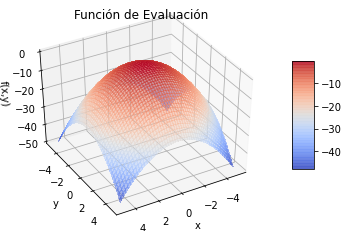

In [ ]:
import math
def f(X_vars):
    return -sum( [xi**2 for xi in X_vars] )

bounds_F = [(-5,5), (-5,5)]
graficarCaminata(f, [], bounds_F, 0.1)

#... COMPLETAR ...#

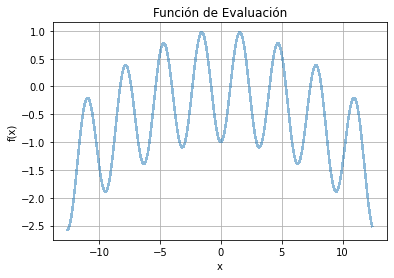

In [ ]:
import math
def g(X_vars):
    return -0.01 * sum([xi**2 for xi in X_vars]) - sum([math.cos(2*xi) for xi in X_vars])

bounds_g = [(-4*math.pi, 4*math.pi)]
graficarCaminata(g, [], bounds_g, 0.1)

#... COMPLETAR ...#

In [ ]:
import math
bounds_G = [(-4*math.pi, 4*math.pi) for i in range (2)]
graficarCaminata(g, [], bounds_G, 0.1)

#... COMPLETAR ...#